### Exercise: Planning a telescope observation



To find where chunk is non-trivial. An example would be try to average all points from the last one, at different points, up to a value that discosts enough from a given value. Bah do it by eyes.

--- DATASET COMPLETO (Con Burn-in) ---
p(clear) stimato = 0.8387 (+0.0027 / -0.0026)

--- DATASET RIPULITO (Post Burn-in) ---
p(clear) stimato = 0.8389 (+0.0026 / -0.0024)



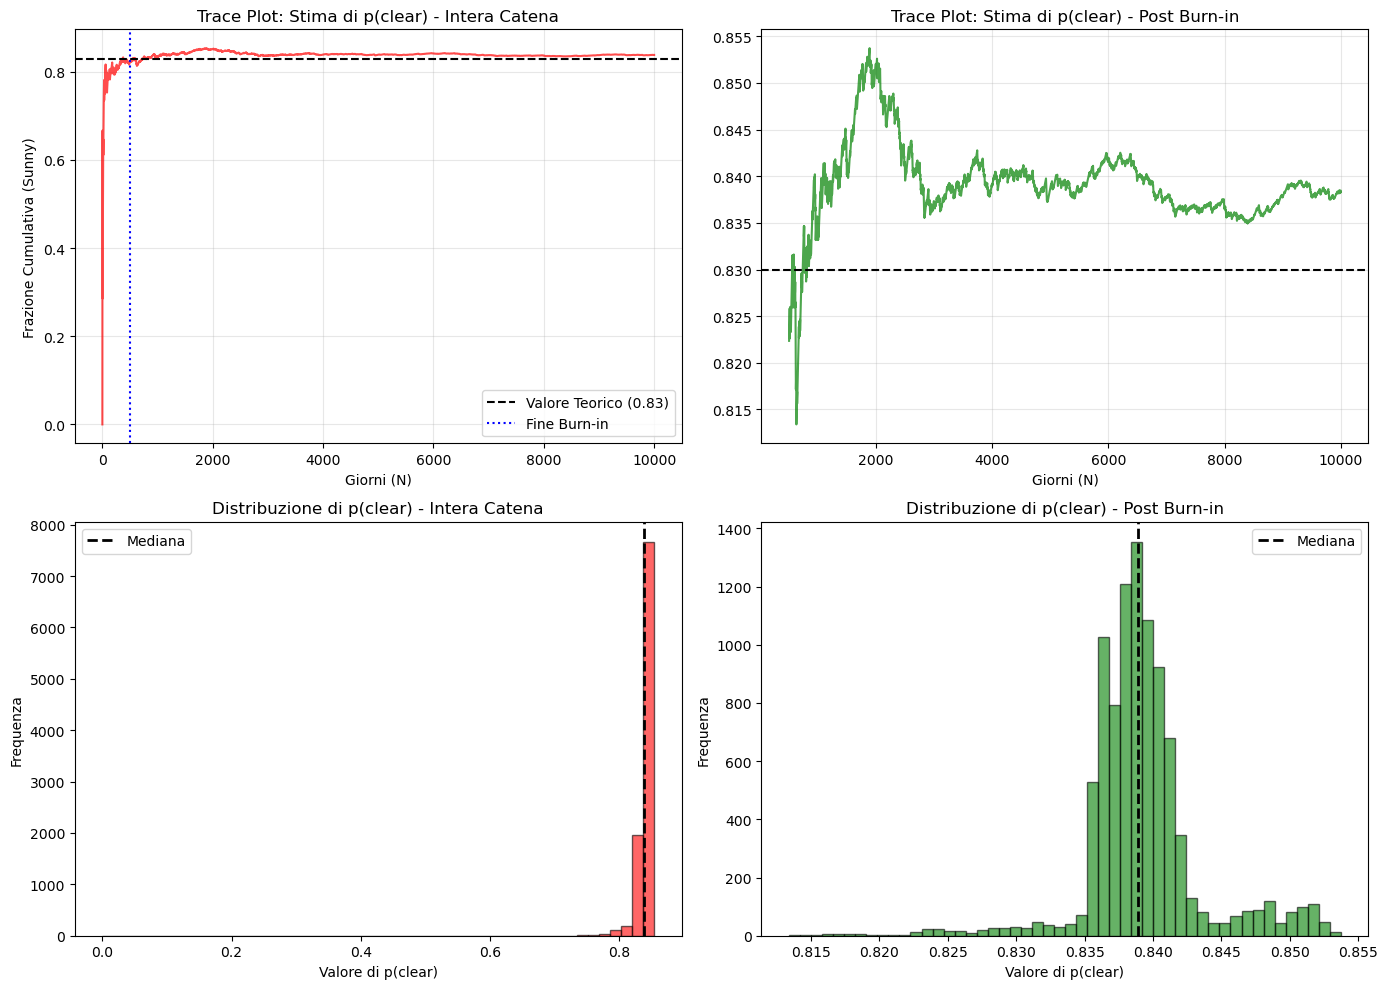

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 10000
burn_in = 500

stati = np.zeros(N)
stati[0] = 0 


for i in range(1, N):
    if stati[i-1] == 0: 
        stati[i] = np.random.choice([0, 1], p=[0.5, 0.5])
    else:
        stati[i] = np.random.choice([0, 1], p=[0.1, 0.9])

sunny_days_cumulati = np.cumsum(stati)
giorni_trascorsi = np.arange(1, N + 1)

p_clear_trace = sunny_days_cumulati / giorni_trascorsi

#Dataset senza il chunk iniziale
p_clear_trace_post_burn = p_clear_trace[burn_in:]

def calcola_statistiche(dati, nome_dataset):
    mediana = np.median(dati)
    p16 = np.percentile(dati, 16)
    p84 = np.percentile(dati, 84)
    err_inf = mediana - p16
    err_sup = p84 - mediana
    print(f"--- {nome_dataset} ---")
    print(f"p(clear) stimato = {mediana:.4f} (+{err_sup:.4f} / -{err_inf:.4f})\n")

calcola_statistiche(p_clear_trace, "DATASET COMPLETO (Con Burn-in)")
calcola_statistiche(p_clear_trace_post_burn, "DATASET RIPULITO (Post Burn-in)")

fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# --- Trace Plot (Tutti i dati) ---
ax[0, 0].plot(giorni_trascorsi, p_clear_trace, color='red', alpha=0.7)
ax[0, 0].axhline(0.83, color='black', linestyle='--', label='Valore Teorico (0.83)')
ax[0, 0].axvline(burn_in, color='blue', linestyle=':', label='Fine Burn-in')
ax[0, 0].set_title('Trace Plot: Stima di p(clear) - Intera Catena')
ax[0, 0].set_xlabel('Giorni (N)')
ax[0, 0].set_ylabel('Frazione Cumulativa (Sunny)')
ax[0, 0].legend()
ax[0, 0].grid(True, alpha=0.3)

# --- Trace Plot (Post Burn-in) ---
ax[0, 1].plot(giorni_trascorsi[burn_in:], p_clear_trace_post_burn, color='green', alpha=0.7)
ax[0, 1].axhline(0.83, color='black', linestyle='--', label='Valore Teorico (0.83)')
ax[0, 1].set_title('Trace Plot: Stima di p(clear) - Post Burn-in')
ax[0, 1].set_xlabel('Giorni (N)')
ax[0, 1].grid(True, alpha=0.3)

# --- Istogramma (Tutti i dati) ---
ax[1, 0].hist(p_clear_trace, bins=50, color='red', alpha=0.6, edgecolor='black')
ax[1, 0].axvline(np.median(p_clear_trace), color='black', linestyle='dashed', linewidth=2, label='Mediana')
ax[1, 0].set_title('Distribuzione di p(clear) - Intera Catena')
ax[1, 0].set_xlabel('Valore di p(clear)')
ax[1, 0].set_ylabel('Frequenza')
ax[1, 0].legend()

# --- Istogramma (Post Burn-in) ---
ax[1, 1].hist(p_clear_trace_post_burn, bins=50, color='green', alpha=0.6, edgecolor='black')
ax[1, 1].axvline(np.median(p_clear_trace_post_burn), color='black', linestyle='dashed', linewidth=2, label='Mediana')
ax[1, 1].set_title('Distribuzione di p(clear) - Post Burn-in')
ax[1, 1].set_xlabel('Valore di p(clear)')
ax[1, 1].set_ylabel('Frequenza')
ax[1, 1].legend()

plt.tight_layout()
plt.show()